# Fermeture $w_{sec}\partial_z\bar u$ du flux de Reynolds — correction $\theta/T$, extension verticale, cadre bulk-plume (Romps 2014)
## Méso-NH RCE `large300`

Notebook indépendant. Reprend le setup commun et refait, dans l'ordre, tous les calculs du notebook précédent (sans les réafficher un par un), pour arriver directement à la comparaison finale 2–8 km. La suite répond point par point aux questions posées sur papier : correction $\theta/T$ de l'équilibre radiatif-subsident, extension au-dessus de 8 km et abandon en dessous de 1.5–2 km, comparaison $\theta_c$ (nuage) vs $\bar\theta$ (environnement) via un diagnostic d'entraînement à la Romps (2014), test des hypothèses H1/H2 sur le bilan de moment en flux de masse, et une métrique de comparaison dépendante de $z$ plus informative qu'une simple corrélation globale.

## §0. Setup commun (identique aux notebooks précédents)

In [133]:
# ============================================================
#  SETUP COMMUN
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; cp=1004.0; p_ref=1e5
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000); m812=(alt>=8000)&(alt<=12000)
m015=(alt>=0)&(alt<=2000)

t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0
tt=np.arange(n_stat)

ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; mh_flat=mh.ravel(); ms_flat=ms.ravel()
f_h=float(mh.mean()); f_s=float(ms.mean())
del prw_all; gc.collect()

def smooth_t(fld, win=8):
    return uniform_filter1d(fld, size=win, axis=1, mode='nearest')

print(f'{n_t}t x {n_z}z x {n_y}y x {n_x}x | humide={f_h:.0%} sec={f_s:.0%}')


100t x 74z x 128y x 2000x | humide=43% sec=57%


## §1. Recalcul groupé des champs du notebook précédent (silencieux)

In [134]:
# ============================================================
#  rho0(z), theta(z,t), T(z,t)  — domaine total
# ============================================================
rho0_sum=np.zeros(n_z); n_rho=0
theta_zt=np.zeros((n_z,n_stat)); T_zt=np.zeros((n_z,n_stat))
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa'))
for iz in range(n_z):
    T=ds_ta['ta'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    p=ds_pa['pa'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    theta=T*(p_ref/p)**(Rd/cp)
    theta_zt[iz]=theta.mean(axis=1); T_zt[iz]=T.mean(axis=1)
    del T,p,theta
ds_ta.close(); ds_pa.close(); gc.collect()
dthetadz_zt=np.gradient(theta_zt, alt, axis=0)
print('rho0, theta_zt, T_zt, dthetadz_zt : ok')


rho0, theta_zt, T_zt, dthetadz_zt : ok


In [135]:
# ============================================================
#  ubar_zt, wbar_zt, flux_zt (u'w') — domaine total
#  + u_h_zt/u_s_zt, w_h_zt/w_s_zt — decomposition humide/sec
# ============================================================
ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat)); flux_zt=np.zeros((n_z,n_stat))
u_h_zt=np.zeros((n_z,n_stat)); u_s_zt=np.zeros((n_z,n_stat))
w_h_zt=np.zeros((n_z,n_stat)); w_s_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    ub=u.mean(axis=1); wb=w.mean(axis=1); up=u-ub[:,None]; wp=w-wb[:,None]
    ubar_zt[iz]=ub; wbar_zt[iz]=wb; flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=1)
    u_h_zt[iz]=u[:,mh_flat].mean(axis=1); u_s_zt[iz]=u[:,ms_flat].mean(axis=1)
    w_h_zt[iz]=w[:,mh_flat].mean(axis=1); w_s_zt[iz]=w[:,ms_flat].mean(axis=1)
    del u,w,ub,wb,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

dudz_tot=np.gradient(ubar_zt, alt, axis=0)
uw_zt=flux_zt/rho0[:,None]
terme_flux=smooth_t(-(1/rho0[:,None])*np.gradient(flux_zt, alt, axis=0))
dudz_tot_s=smooth_t(dudz_tot); w_s_obs_s=smooth_t(w_s_zt)
print('ubar_zt, wbar_zt, flux_zt, u_h/s_zt, w_h/s_zt, terme_flux : ok')


ubar_zt, wbar_zt, flux_zt, u_h/s_zt, w_h/s_zt, terme_flux : ok


In [136]:
# ============================================================
#  tntr(z,t) domaine total — tendance radiative
# ============================================================
tntr_zt=np.zeros((n_z,n_stat))
ds_tntr=xr.open_dataset(path3d('tntr'))
for iz in range(n_z):
    tr=ds_tntr['tntr'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    tntr_zt[iz]=tr.mean(axis=1)
    del tr
ds_tntr.close(); gc.collect()

with np.errstate(divide='ignore', invalid='ignore'):
    w_sec_rce_brut     = -tntr_zt/dthetadz_zt                      # sans correction theta/T
    w_sec_rce_corrige  = -(theta_zt/T_zt)*tntr_zt/dthetadz_zt      # avec correction theta/T (H0)
w_sec_rce_brut_s    = smooth_t(w_sec_rce_brut)
w_sec_rce_corrige_s = smooth_t(w_sec_rce_corrige)
w_sec_rce_x_shear    = smooth_t(w_sec_rce_corrige*dudz_tot)
print('tntr_zt, w_sec_rce (brut+corrige), fermeture finale : ok')


tntr_zt, w_sec_rce (brut+corrige), fermeture finale : ok


## §2. Affichage final — fermeture complète sur 2–8 km

/tmp/ipykernel_39442/1514850730.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m28], fld[m28], cmap='RdBu_r',


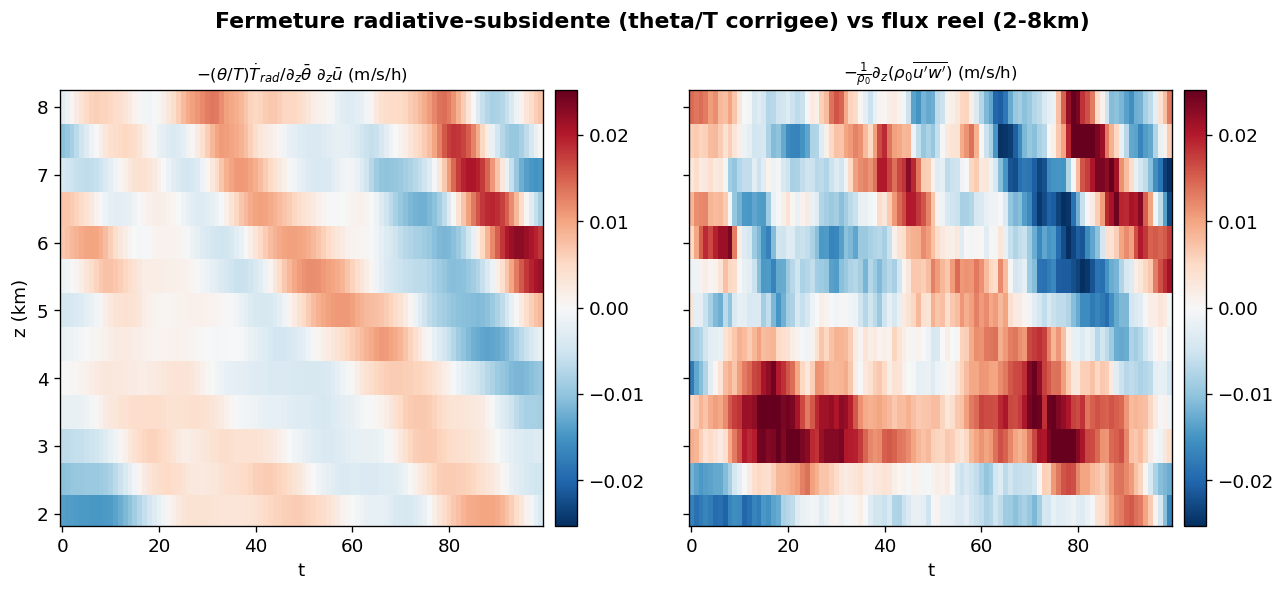

In [137]:
# ============================================================
#  terme_flux vs w_sec_rce_corrige * dudz_tot, 2-8km
# ============================================================
fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.percentile(np.abs(terme_flux[m28]),98), np.percentile(np.abs(w_sec_rce_x_shear[m28]),98))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(w_sec_rce_x_shear*3600, r"$-(\theta/T)\dot T_{rad}/\partial_z\bar\theta\ \partial_z\bar u$ (m/s/h)"),
                                (terme_flux*3600, r"$-\frac{1}{\rho_0}\partial_z(\rho_0\overline{u'w'})$ (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m28], fld[m28], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle('Fermeture radiative-subsidente (theta/T corrigee) vs flux reel (2-8km)', fontweight='bold')
plt.tight_layout(); plt.show()



## §3. La correction $\theta/T$ améliore-t-elle vraiment l'ajustement ? (H0 du tableau)

$$w_{sec}\,\partial_z\bar\theta = \frac{\theta}{T}\dot T_{rad} \quad\text{(H0, tableau)}$$

On compare $w_{sec}$ observé (zone sèche) à sa version prédite **sans** le facteur $\theta/T$ (ce que le premier essai avait fait par erreur) et **avec** ce facteur — le facteur croit avec l'altitude, donc l'écart entre les deux versions doit se creuser en montant.

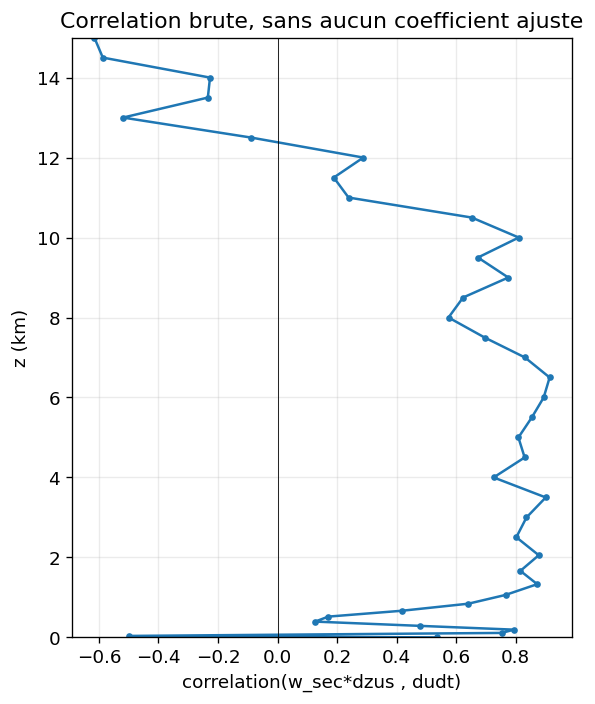

In [138]:
# ============================================================
#  Comparaison SANS regression : correlation brute, niveau par niveau
# ============================================================
r_brut = np.full(n_z, np.nan)
for iz in range(n_z):
    x, y = w_sec_rce_x_shear[iz,:],terme_flux[iz,:]
    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15: continue
    r_brut[iz] = np.corrcoef(x,y)[0,1]
 
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(r_brut[mask_show], zkm[mask_show], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('correlation(w_sec*dzus , dudt)'); ax.set_ylabel('z (km)'); ax.set_ylim(0,Z_TOP_KM)
ax.set_title("Correlation brute, sans aucun coefficient ajuste")
plt.tight_layout(); plt.show()


## §5. $\theta_c$ (nuage) vs $\bar\theta$ (environnement) — diagnostic d'entraînement à la Romps (2014)



In [139]:
# ============================================================
#  theta_c = theta restreinte a la zone humide (meme construction que theta_zt, masque mh)
# ============================================================
theta_c_zt = np.zeros((n_z, n_stat))
ds_ta = xr.open_dataset(path3d('ta')); ds_pa = xr.open_dataset(path3d('pa'))
for iz in range(n_z):
    T = ds_ta['ta'].isel({dim_t:idx_stat, dim_z:iz}).values.reshape(n_stat,-1)
    p = ds_pa['pa'].isel({dim_t:idx_stat, dim_z:iz}).values.reshape(n_stat,-1)
    theta = T*(p_ref/p)**(Rd/cp)
    theta_c_zt[iz] = theta[:,mh_flat].mean(axis=1)   # moyenne sur les colonnes humides uniquement
    del T,p,theta
ds_ta.close(); ds_pa.close(); gc.collect()

15258

In [172]:
# ============================================================
#  epsilon(z,t) : dz(theta_c) = eps*(theta_bar - theta_c), point par point (plus composite)
# ============================================================
'''theta_c_dz_zt = np.gradient(theta_c_zt, alt, axis=0)
denom_zt = theta_zt - theta_c_zt
seuil_denom = 0.001
with np.errstate(divide='ignore', invalid='ignore'):
    eps_zt = np.where(np.abs(denom_zt) > seuil_denom, dtheta_c_dz_zt/denom_zt, np.nan)'''

# ============================================================
#  epsilon via le vent (Romps eq.18) : dz(uc) = eps*(ubar - uc)  =>  eps = dz(uc)/(ubar-uc)
#  uc = u_h_zt (zone humide, proxy nuage), ubar = ubar_zt (domaine total)
# ============================================================
duc_dz_zt = np.gradient(u_h_zt, alt, axis=0)
denom_u_zt = ubar_zt - u_h_zt
eps_zt = duc_dz_zt/denom_u_zt

'''seuil_denom_u = 0
with np.errstate(divide='ignore', invalid='ignore'):
    eps_zt = np.where(np.abs(denom_u_zt) > seuil_denom_u, duc_dz_zt/denom_u_zt, np.nan)

print('eps_zt (2-8km) : median =', np.nanmedian(np.abs(eps_zt[m28])),
      '| max =', np.nanmax(np.abs(eps_zt[m28])))

fig, ax = plt.subplots(figsize=(6,7))
ax.plot(np.nanmedian(eps_zt, axis=1)[mask_show]*1e3, zkm[mask_show], 'o-', ms=3)
ax.axvline(0,color='k',lw=.5)
ax.set_xlabel(r'$\varepsilon_u$ ($10^{-3}$ m$^{-1}$)'); ax.set_ylabel('z (km)')
ax.set_title(r"Entrainement diagnostique sur le vent : $\partial_z u_c=\varepsilon(\bar u-u_c)$")
plt.tight_layout(); plt.show()'''

<>:18: SyntaxWarning: invalid escape sequence '\p'
<>:18: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_39442/1743438480.py:18: SyntaxWarning: invalid escape sequence '\p'
  '''seuil_denom_u = 0


'seuil_denom_u = 0\nwith np.errstate(divide=\'ignore\', invalid=\'ignore\'):\n    eps_zt = np.where(np.abs(denom_u_zt) > seuil_denom_u, duc_dz_zt/denom_u_zt, np.nan)\n\nprint(\'eps_zt (2-8km) : median =\', np.nanmedian(np.abs(eps_zt[m28])),\n      \'| max =\', np.nanmax(np.abs(eps_zt[m28])))\n\nfig, ax = plt.subplots(figsize=(6,7))\nax.plot(np.nanmedian(eps_zt, axis=1)[mask_show]*1e3, zkm[mask_show], \'o-\', ms=3)\nax.axvline(0,color=\'k\',lw=.5)\nax.set_xlabel(r\'$\x0barepsilon_u$ ($10^{-3}$ m$^{-1}$)\'); ax.set_ylabel(\'z (km)\')\nax.set_title(r"Entrainement diagnostique sur le vent : $\\partial_z u_c=\x0barepsilon(\x08ar u-u_c)$")\nplt.tight_layout(); plt.show()'

In [141]:
# ============================================================
#  M(z,t) : flux de masse convectif = rho0 * f_h * w_h_zt
#  D(z,t) : detrainement, via continuite dz(M) = (eps - D) M  =>  D = eps - dz(M)/M
# ============================================================
'''M_zt = rho0[:,None] * f_h * w_h_zt                wbar_zt
dMdz_zt = np.gradient(M_zt, alt, axis=0)
D_zt = eps_zt - dMdz_zt/M_zt'''

D_zt = smooth_t(np.gradient(w_s_zt, alt, axis=0)) #avec w_s_obs_s=smooth_t(w_s_zt) et w_s_zt[iz]=w[:,ms_flat].mean(axis=1)

In [175]:
#TRICHE
M_zt = rho0[:,None] * f_h * w_h_zt            
dMdz_zt = np.gradient(M_zt, alt, axis=0)
eps_zt = D_zt - dMdz_zt/M_zt

In [142]:


# ============================================================
#  Nouvelle estimation de dudt : rho0*dt(ubar) = dz[M*(ubar - uc)]   (Romps eq. 2, uc = u_h_zt)
# ============================================================
w_sec_rce_corrige_2  = -(theta_c_zt/T_zt)*tntr_zt/dtheta_c_dz_zt
dudt_pred_zt =  w_sec_rce_corrige_2*dudz_tot

/tmp/ipykernel_39442/468200729.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[mask_show], theta_c_zt[mask_show], cmap='RdBu_r', shading='auto')
/tmp/ipykernel_39442/468200729.py:13: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[mask_show], smooth_t(eps_zt[mask_show]*1e3), cmap='RdBu_r',
/tmp/ipykernel_39442/468200729.py:19: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[mask_show], smooth_t(D_zt[mask_show]*1e3), cmap='RdBu_r',
/tmp/ipykernel_39442/468200729.py:25: MatplotlibD

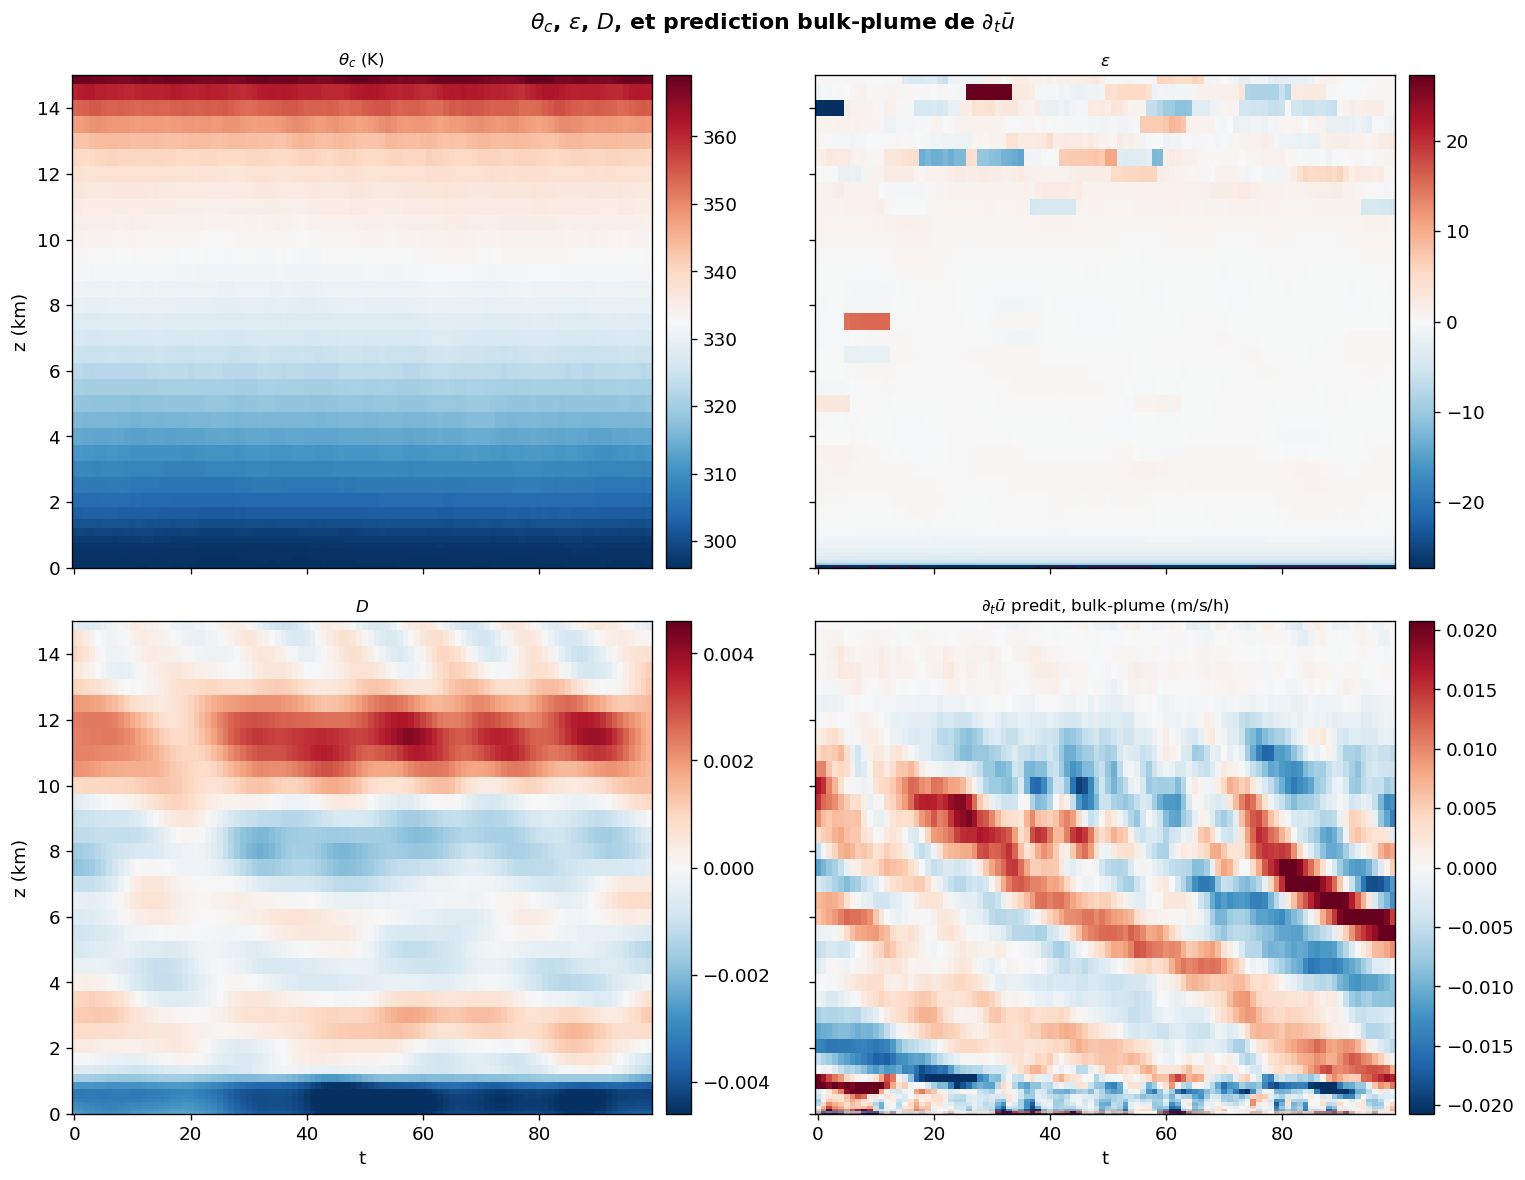

In [176]:



# ============================================================
#  Affichage : theta_c, epsilon, D, dudt_pred — chacun en (z,t)
# ============================================================
fig, axes = plt.subplots(2,2,figsize=(13,10),sharex=True,sharey=True)

ax = axes[0,0]
v = np.percentile(np.abs(theta_c_zt[mask_show]-theta_c_zt[mask_show].mean()),98)+1e-9
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], theta_c_zt[mask_show], cmap='RdBu_r', shading='auto')
ax.set_title(r'$\theta_c$ (K)', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

ax = axes[0,1]
v = np.nanpercentile(np.abs(eps_zt[mask_show]),95)*1e3+1e-12
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], smooth_t(eps_zt[mask_show]*1e3), cmap='RdBu_r',
                    norm=TwoSlopeNorm(0,-v,v), shading='auto')
ax.set_title(r'$\varepsilon$', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

ax = axes[1,0]
v = np.nanpercentile(np.abs(D_zt[mask_show]),95)*1e3+1e-12
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], smooth_t(D_zt[mask_show]*1e3), cmap='RdBu_r',
                    norm=TwoSlopeNorm(0,-v,v), shading='auto')
ax.set_title(r'$D$', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

ax = axes[1,1]
v = np.nanpercentile(np.abs(dudt_pred_zt[mask_show]),98)*3600+1e-12
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_pred_zt[mask_show]*3600, cmap='RdBu_r',
                    norm=TwoSlopeNorm(0,-v,v), shading='auto')
ax.set_title(r'$\partial_t\bar u$ predit, bulk-plume (m/s/h)', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

for ax in axes[:,0]: ax.set_ylabel('z (km)')
for ax in axes[1,:]: ax.set_xlabel('t')
axes[0,0].set_ylim(0,Z_TOP_KM)
plt.suptitle(r"$\theta_c$, $\varepsilon$, $D$, et prediction bulk-plume de $\partial_t\bar u$", fontweight='bold')
plt.tight_layout(); plt.show()

In [144]:
dudt_tot_raw = np.gradient(ubar_zt, dt_phys, axis=1)
dudt_tot = smooth_t(dudt_tot_raw)


/tmp/ipykernel_39442/417204437.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_tot[mask_show], cmap='RdBu_r', shading='auto')
/tmp/ipykernel_39442/417204437.py:11: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_pred_zt[mask_show]*3600, cmap='RdBu_r',


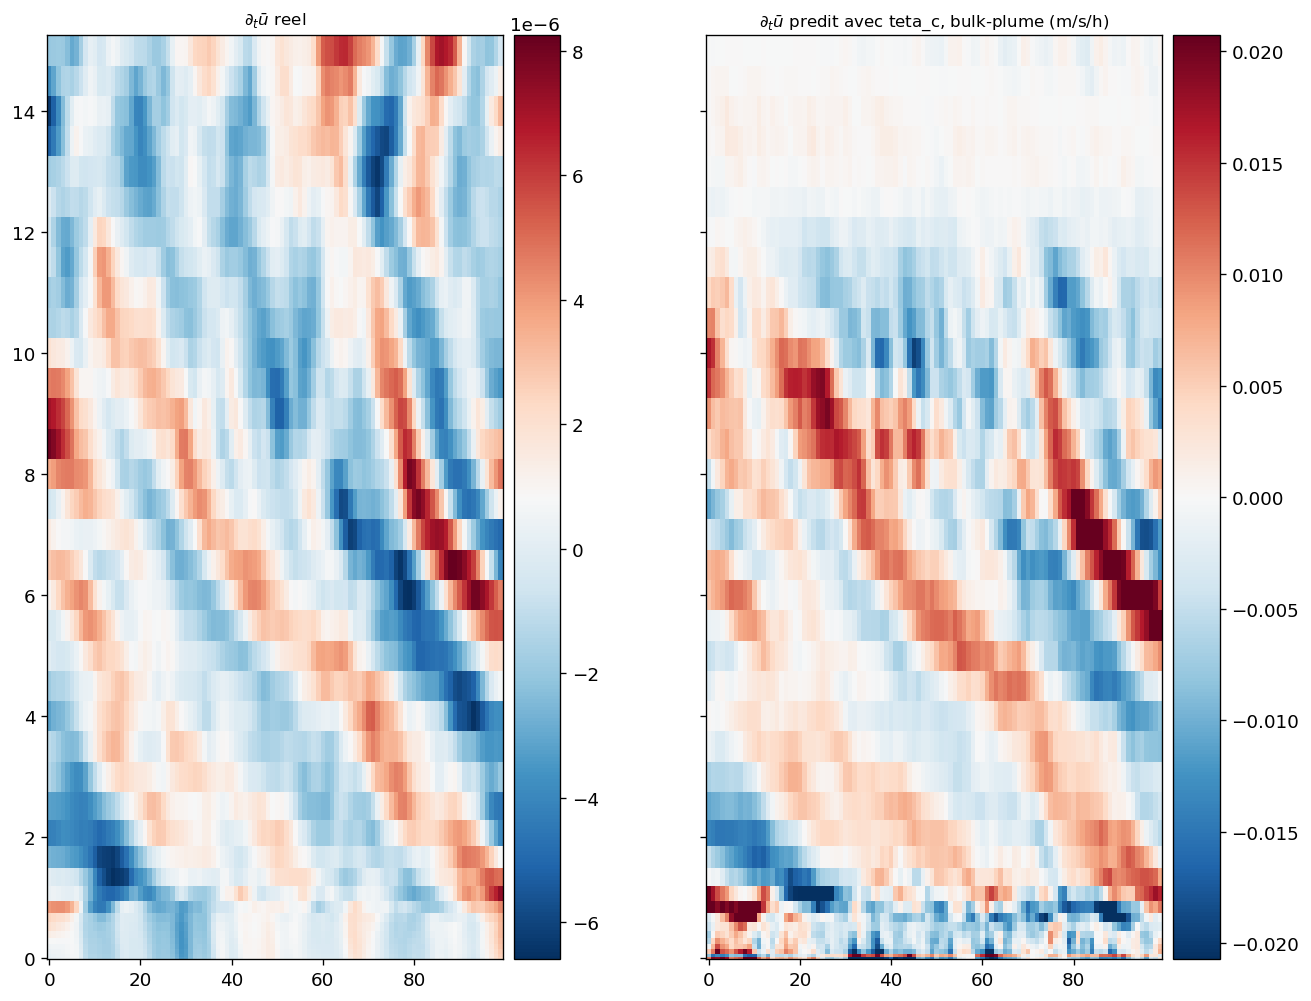

In [145]:
# ============================================================
#  Affichage : theta_c, epsilon, D, dudt_pred — chacun en (z,t)
# ============================================================
fig, axes = plt.subplots(1,2,figsize=(13,10),sharex=True,sharey=True)

ax = axes[0]
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_tot[mask_show], cmap='RdBu_r', shading='auto')
ax.set_title(r'$\partial_t\bar u$ reel', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

ax = axes[1]
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_pred_zt[mask_show]*3600, cmap='RdBu_r',
                    norm=TwoSlopeNorm(0,-v,v), shading='auto')
ax.set_title(r'$\partial_t\bar u$ predit avec teta_c, bulk-plume (m/s/h)', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

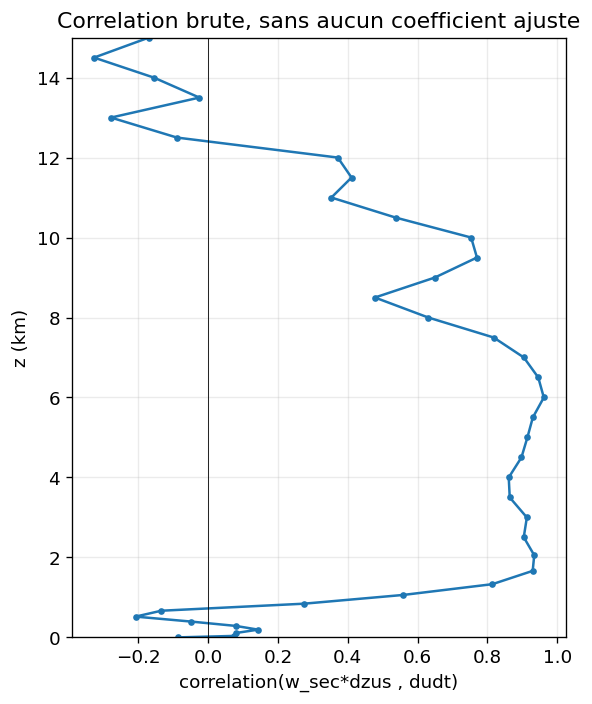

In [146]:
# ============================================================
#  Comparaison SANS regression : correlation brute, niveau par niveau
# ============================================================
r_brut = np.full(n_z, np.nan)
for iz in range(n_z):
    x, y = dudt_tot[iz,:],dudt_pred_zt[iz,:]
    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15: continue
    r_brut[iz] = np.corrcoef(x,y)[0,1]
 
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(r_brut[mask_show], zkm[mask_show], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('correlation(w_sec*dzus , dudt)'); ax.set_ylabel('z (km)'); ax.set_ylim(0,Z_TOP_KM)
ax.set_title("Correlation brute, sans aucun coefficient ajuste")
plt.tight_layout(); plt.show()


## §6. Bilan en flux de masse (tableau blanc) — test des hypothèses H1 et H2

Dérivation du tableau (bilan sur une tranche $\delta z$, à la Romps 2012b/2014) :

$$T_u = -w_{sec}\,\partial_z\bar u + D\,(u_c-\bar u)$$

**(H1)** $|D(u_c-\bar u)| \ll |w_{sec}\partial_z\bar u| \Rightarrow T_u\approx w_{sec}\partial_z\bar u$ (c'est l'approximation qu'on a testée implicitement jusqu'ici).

**(H2)** $D=\partial_z w_{sec}$ (continuité de masse) et $\varepsilon\ll D$.

/tmp/ipykernel_39442/1017188676.py:15: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',


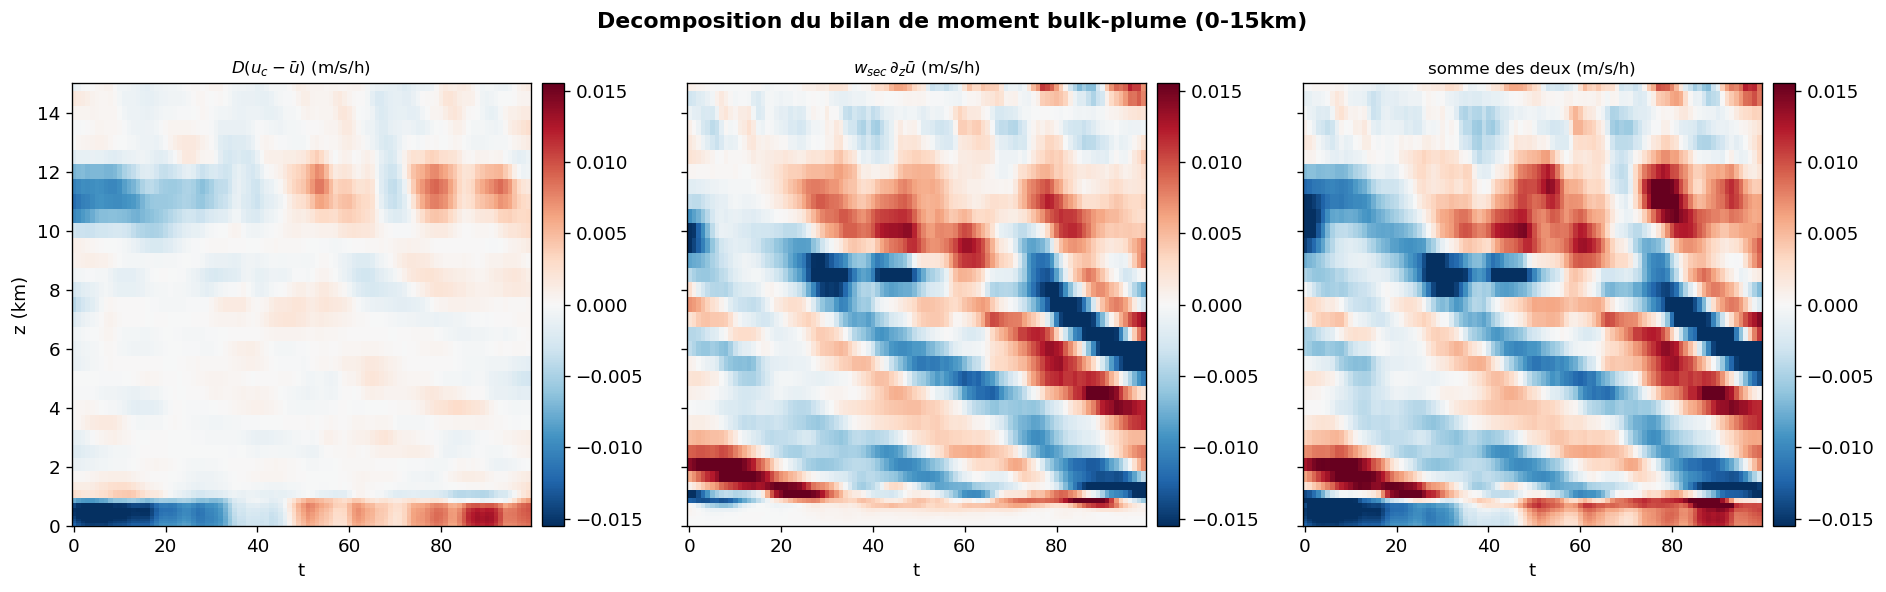

In [148]:
# ============================================================
#  D(uc-ubar) vs w_sec*dudz(ubar) vs leur somme, en (z,t) sur 0-15km
# ============================================================
terme_detrainement = smooth_t(D_zt * (u_h_zt - ubar_zt))
terme_advectif = smooth_t(w_s_zt * dudz_tot)
somme_termes = terme_detrainement + terme_advectif

fig, axes = plt.subplots(1,3,figsize=(16,5),sharey=True)
v = max(np.nanpercentile(np.abs(terme_detrainement[mask_show]),95),
        np.nanpercentile(np.abs(terme_advectif[mask_show]),95),
        np.nanpercentile(np.abs(somme_termes[mask_show]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(terme_detrainement*3600, r"$D(u_c-\bar u)$ (m/s/h)"),
                                (terme_advectif*3600, r"$w_{sec}\,\partial_z\bar u$ (m/s/h)"),
                                (somme_termes*3600, "somme des deux (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)'); axes[0].set_ylim(0,Z_TOP_KM)
plt.suptitle("Decomposition du bilan de moment bulk-plume (0-15km)", fontweight='bold')
plt.tight_layout(); plt.show()

/tmp/ipykernel_39442/2759712371.py:12: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m812], fld[m812], cmap='RdBu_r',


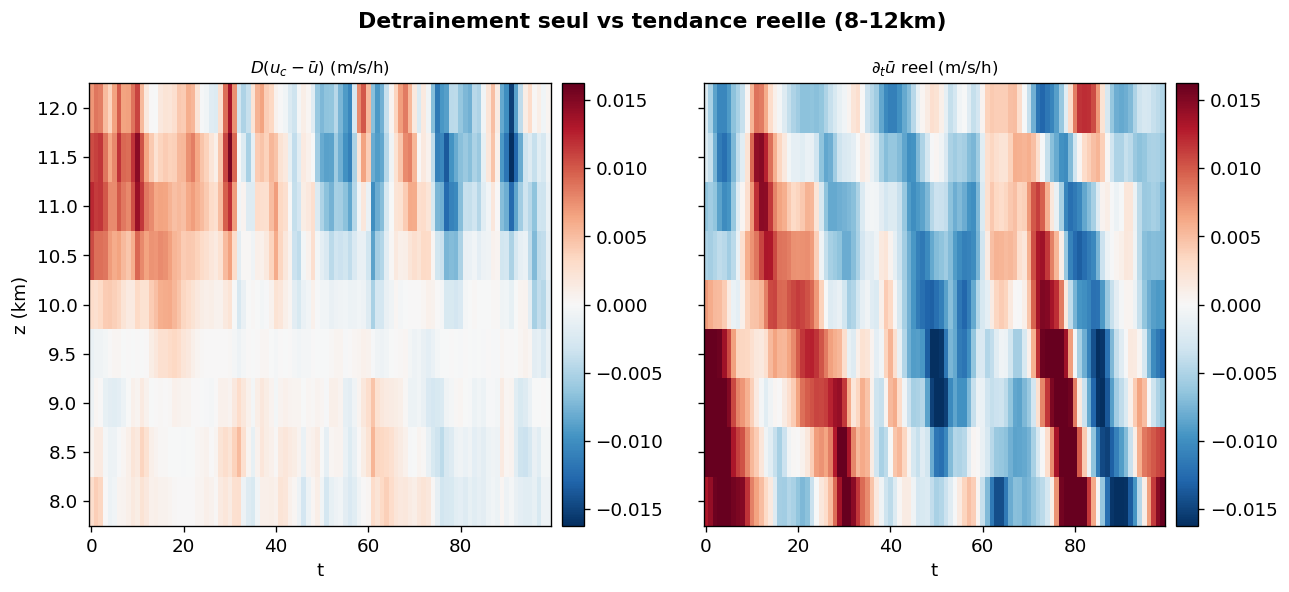

In [155]:
# ============================================================
#  D(uc-ubar) vs dudt reel, sur 8-12km
# ============================================================
terme_detrainement = D_zt * (u_h_zt - ubar_zt)
dudt_reel = smooth_t(np.gradient(ubar_zt, dt_phys, axis=1))

fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.nanpercentile(np.abs(terme_detrainement[m812]),95),
        np.nanpercentile(np.abs(dudt_reel[m812]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(-terme_detrainement*3600, r"$D(u_c-\bar u)$ (m/s/h)"),
                                (dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m812], fld[m812], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Detrainement seul vs tendance reelle (8-12km)", fontweight='bold')
plt.tight_layout(); plt.show()

/tmp/ipykernel_39442/738667046.py:10: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m812], fld[m812], cmap='RdBu_r',


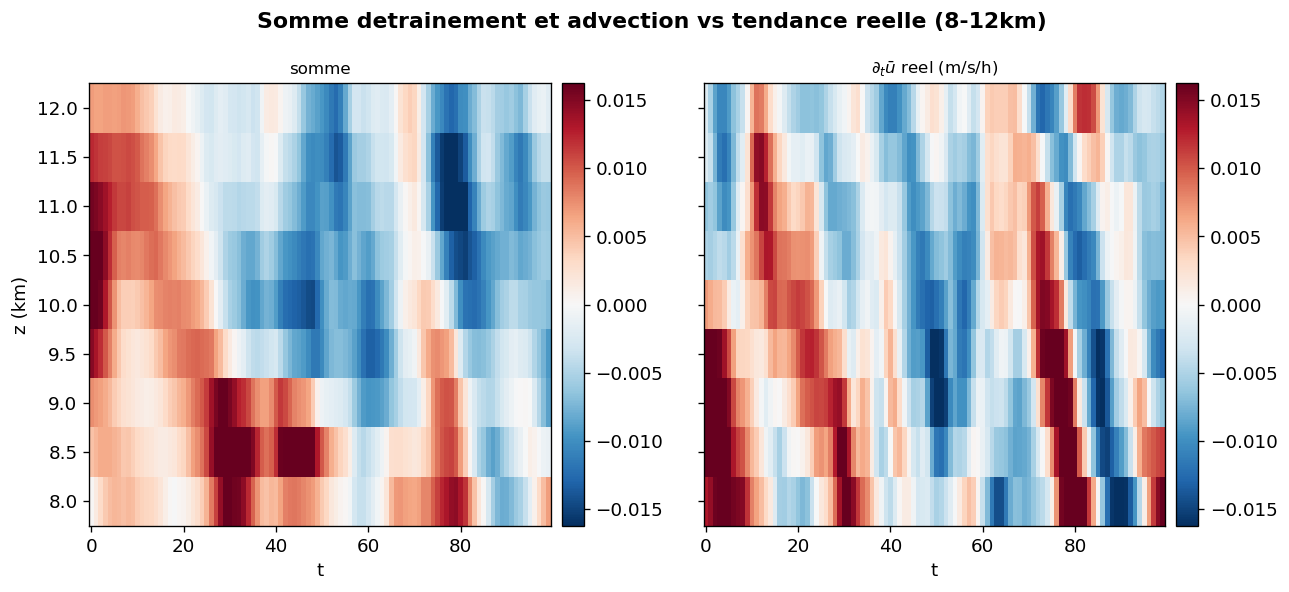

In [157]:
# ============================================================
#  D(uc-ubar) vs dudt reel, sur 8-12km
# ============================================================

fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.nanpercentile(np.abs(somme_termes[m812]),95),
        np.nanpercentile(np.abs(dudt_reel[m812]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(-somme_termes*3600, r"somme"),
                                (dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m812], fld[m812], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Somme detrainement et advection vs tendance reelle (8-12km)", fontweight='bold')
plt.tight_layout(); plt.show()

/tmp/ipykernel_39442/3056927787.py:23: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',


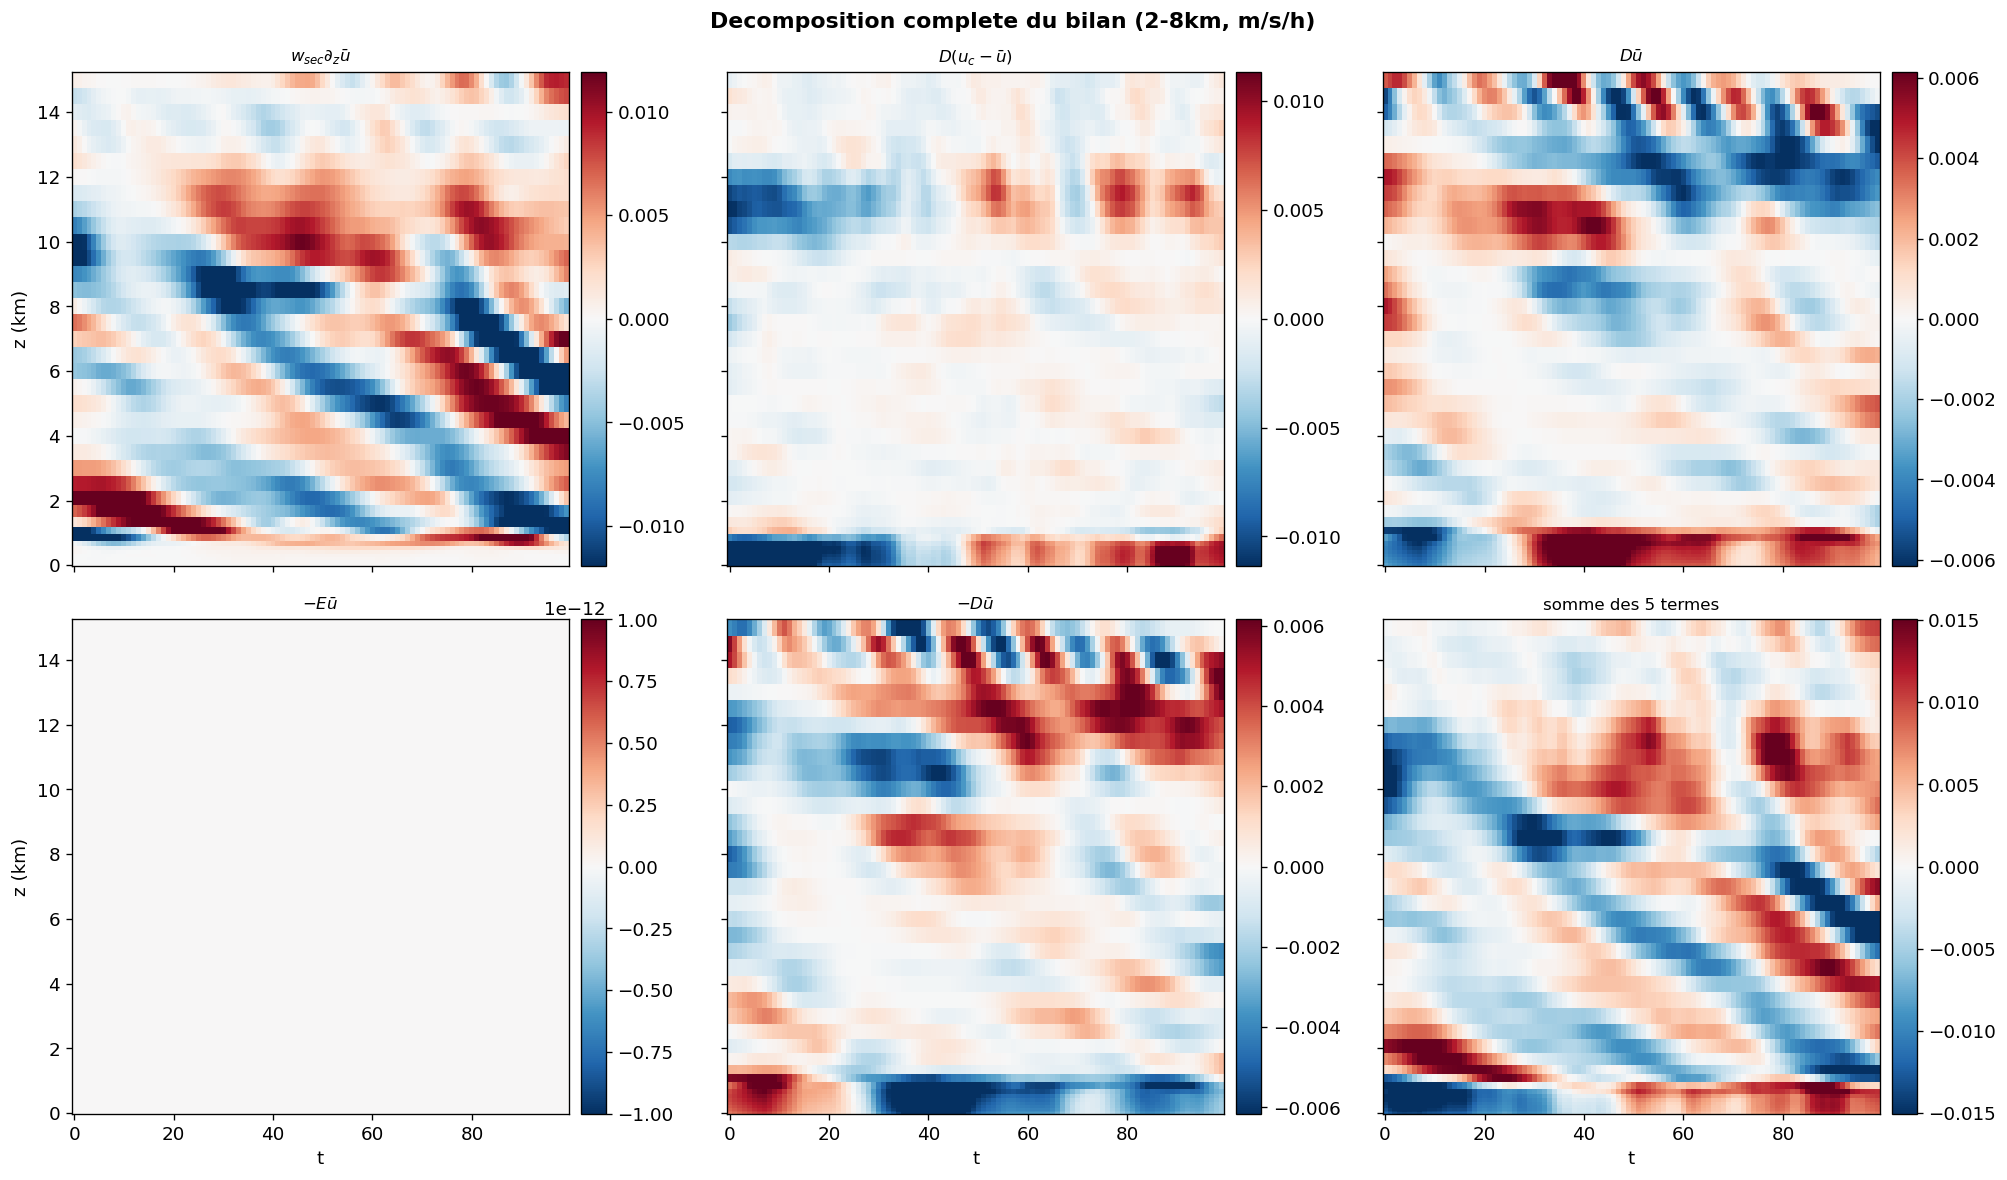

/tmp/ipykernel_39442/3056927787.py:40: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',


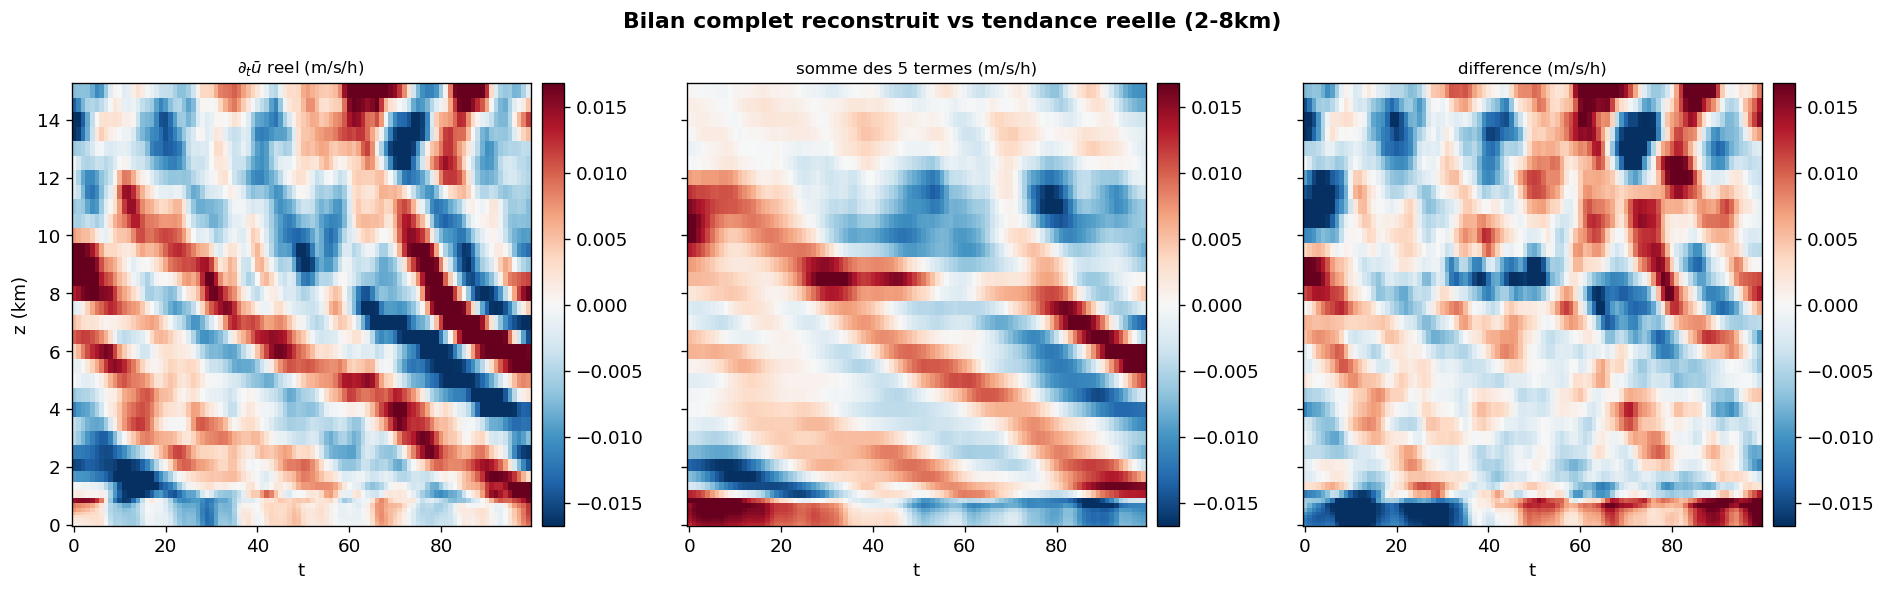

In [178]:
# ============================================================
#  Tous les termes du bilan de moment, affiches separement en (z,t)
#  Tu = w_sec*dudz(ubar) + D(uc-ubar) + D*ubar - E*ubar - D*ubar
#  E = eps_zt (taux d'entrainement), D = D_zt, uc = u_h_zt
# ============================================================
terme1_advectif   = smooth_t(w_s_obs_s * dudz_tot_s)          #  w_sec * dz(ubar)
terme2_detrain_uc = smooth_t(D_zt * (u_h_zt - ubar_zt) )       #  D*(uc-ubar)
terme3_D_ubar     = smooth_t(D_zt * ubar_zt   )                 #  D*ubar
terme4_E_ubar     = 0*smooth_t(-eps_zt * ubar_zt )                # -E*ubar
terme5_neg_D_ubar = smooth_t(-D_zt * ubar_zt   )                # -D*ubar

somme_tous = terme1_advectif + terme2_detrain_uc + terme3_D_ubar + terme4_E_ubar + terme5_neg_D_ubar

fig, axes = plt.subplots(2,3,figsize=(17,10),sharex=True,sharey=True)
panels = [(terme1_advectif*3600, r"$w_{sec}\partial_z\bar u$"),
          (terme2_detrain_uc*3600, r"$D(u_c-\bar u)$"),
          (terme3_D_ubar*3600, r"$D\bar u$"),
          (terme4_E_ubar*3600, r"$-E\bar u$"),
          (terme5_neg_D_ubar*3600, r"$-D\bar u$"),
          (somme_tous*3600, "somme des 5 termes")]
for ax,(fld,lab) in zip(axes.ravel(), panels):
    v = np.nanpercentile(np.abs(fld[mask_show]),95)+1e-12
    im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_title(lab, fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
for ax in axes[:,0]: ax.set_ylabel('z (km)')
for ax in axes[1,:]: ax.set_xlabel('t')
plt.suptitle("Decomposition complete du bilan (2-8km, m/s/h)", fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
#  Comparaison : somme des 5 termes vs dudt reel
# ============================================================
fig, axes = plt.subplots(1,3,figsize=(16,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[mask_show]),95), np.nanpercentile(np.abs(somme_tous[mask_show]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes, [(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                 (-somme_tous*3600, "somme des 5 termes (m/s/h)"),
                                 ((dudt_reel+somme_tous)*3600, "difference (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[mask_show], fld[mask_show], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Bilan complet reconstruit vs tendance reelle (2-8km)", fontweight='bold')
plt.tight_layout(); plt.show()

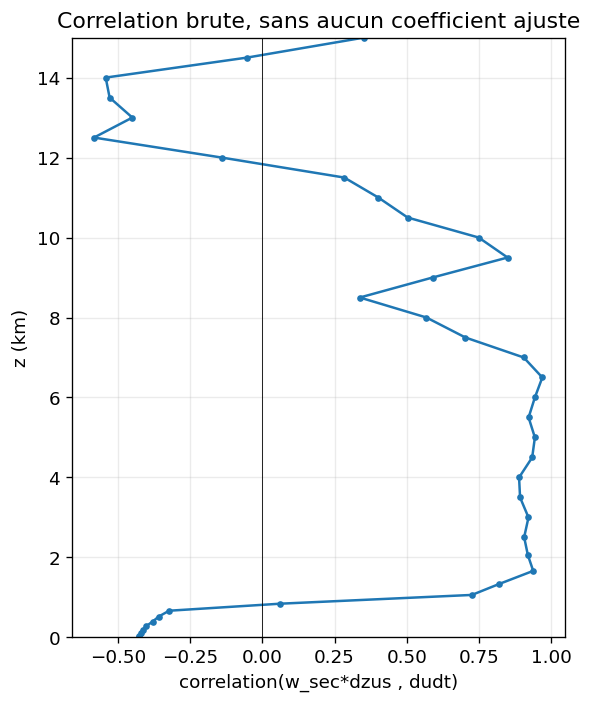

In [179]:
# ============================================================
#  Comparaison SANS regression : correlation brute, niveau par niveau
# ============================================================
r_brut = np.full(n_z, np.nan)
for iz in range(n_z):
    x, y = -somme_tous[iz,:],dudt_reel[iz,:]
    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15: continue
    r_brut[iz] = np.corrcoef(x,y)[0,1]
 
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(r_brut[mask_show], zkm[mask_show], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('correlation(w_sec*dzus , dudt)'); ax.set_ylabel('z (km)'); ax.set_ylim(0,Z_TOP_KM)
ax.set_title("Correlation brute, sans aucun coefficient ajuste")
plt.tight_layout(); plt.show()